# Same task, raw pandas + matplotlib

This is the **verbose** version of the pipeline that `dcleaner` shortens.
Same data, same result — just more boilerplate.

(Companion to `with_dcleaner.ipynb`.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 200
df = pd.DataFrame({
    "City": rng.choice(["NY", "LA", "SF", "CHI"], n),
    "Age": rng.integers(16, 65, n),
    "Salary": rng.integers(30000, 130000, n).astype(float),
    "Score": rng.normal(50, 12, n),
})
df.loc[rng.choice(n, 15, replace=False), "Salary"] = np.nan
df.loc[rng.choice(n, 5, replace=False), "Age"] = rng.integers(10, 15, 5)
df.to_csv("sales_raw.csv", index=False)
df.head()

## Clean + filter (raw pandas)

In [1]:
df = df.dropna()
df = df[df["Age"] > 18]
print(f"{df.shape[0]} rows x {df.shape[1]} cols")
df.head()

172 rows x 4 cols


## Derive a column + aggregate

In [1]:
df = df.copy()
df["salary_k"] = df["Salary"] / 1000
summary = df.groupby("City")["Salary"].mean().reset_index()
summary

## Plot it

saved plot -> salary_by_city_raw.png


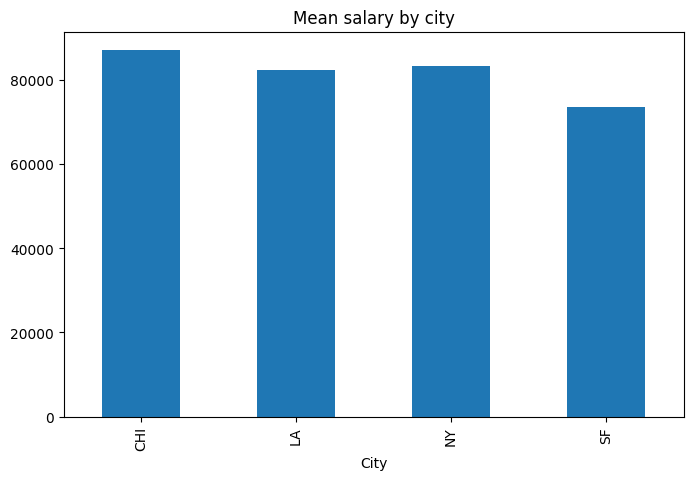

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
summary.plot(kind="bar", x="City", y="Salary", ax=ax, legend=False)
ax.set_title("Mean salary by city")
fig.savefig("salary_by_city_raw.png", bbox_inches="tight")
print("saved plot -> salary_by_city_raw.png")

## Correlation heatmap (raw pandas/matplotlib)

saved plot -> corr_raw.png


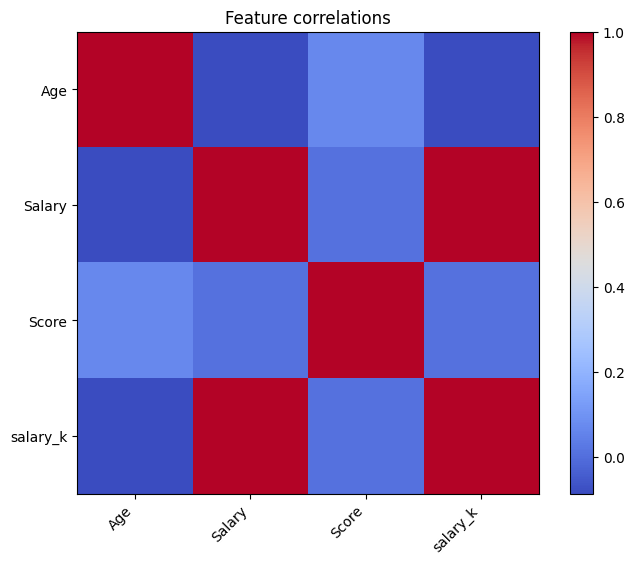

In [1]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax)
ax.set_title("Feature correlations")
fig.savefig("corr_raw.png", bbox_inches="tight")
print("saved plot -> corr_raw.png")